In [1]:
get_ipython().run_line_magic('matplotlib', 'inline')
import sys, platform, json, importlib.metadata, torch
assert not torch.cuda.is_available(), 'CPU teaching lane unexpectedly sees CUDA'
identity = dict(executable=sys.executable, prefix=sys.prefix, python=platform.python_version(), platform=platform.platform(), cuda_available=torch.cuda.is_available(), torch_cuda_build=torch.version.cuda, packages={name:importlib.metadata.version(name) for name in ['torch','numpy','matplotlib','nbformat','nbclient','ipykernel','transformers','tokenizers','peft']})
print('__DONGXI_KERNEL_IDENTITY__:' + json.dumps(identity, sort_keys=True))

__DONGXI_KERNEL_IDENTITY__:{"cuda_available": false, "executable": "/tmp/dongxi-course-reproduction.ZfVaEu/venv/bin/python", "packages": {"ipykernel": "7.4.0", "matplotlib": "3.10.8", "nbclient": "0.11.0", "nbformat": "5.11.1", "numpy": "2.5.3", "peft": "0.20.0", "tokenizers": "0.23.2", "torch": "2.14.1+cpu", "transformers": "5.18.0"}, "platform": "Linux-6.17.0-1031-nvidia-aarch64-with-glibc2.39", "prefix": "/tmp/dongxi-course-reproduction.ZfVaEu/venv", "python": "3.12.14", "torch_cuda_build": null}


# DPO retention: what additional supervision actually changes

Day 18 / Chapter 11 extension. Actual tiny shared decoder, original symbolic fixtures, CPU only, no model downloads. This is a controlled microscope, not a natural-language or pretrained-model benchmark.

Learning arc: predict → inspect the objective → fit every frozen arm → perturb preference labels/length → inspect free generation and separate-task retention → account for information and compute. All coefficients/seeds/budgets were saved before fitting. No best coefficient or checkpoint is selected from held-out results.

[Chapter](../../book/chapters/11-direct-preference-optimization.md) · [Specification](../../experiments/specs/2026-10-04-dpo-retention.md) · [Evidence](../../experiments/reports/2026-10-04-dpo-retention.md)


In [2]:
from pathlib import Path
import sys, json, hashlib
root = Path.cwd().resolve()
while not (root/"src"/"dongxi_llms").is_dir():
    if root.parent == root:
        raise RuntimeError("Open this notebook within the Dongxi_LLMs repository")
    root = root.parent
sys.path.insert(0,str(root/"src"))
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from dongxi_llms import dpo_retention_lab as lab
from dongxi_llms.dpo_lab import dpo_loss
torch.set_num_threads(1)
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","font.family":"DejaVu Sans",
                     "axes.spines.top":False,"axes.spines.right":False,"font.size":10})
contract = lab.load_contract()
arms = [x["name"] for x in contract["arms"]]
conditions = contract["conditions"]
colors = ["#356a9b","#b97139","#3d8268","#7a638d"]
labels = ["DPO","DPO + chosen","DPO + rehearsal","DPO + both"]
print("Frozen seeds:",contract["seeds"])
print("Warm-up:",contract["warmup"],"Fit:",contract["fit"])
print("Coefficients:",contract["arms"])
print("Contract SHA256:",hashlib.sha256((root/"fixtures/dpo-retention/contract.json").read_bytes()).hexdigest())
assert not torch.cuda.is_available(), "Use the CPU teaching kernel"


Frozen seeds: [1811, 1812, 1813]
Warm-up: {'updates': 120, 'lr': 0.015, 'weight_decay': 0.0, 'gradient_clip': 1.0} Fit: {'updates': 80, 'lr': 0.008, 'weight_decay': 0.0, 'gradient_clip': 1.0, 'beta': 0.5}
Coefficients: [{'name': 'dpo', 'alpha': 0.0, 'gamma': 0.0}, {'name': 'dpo+chosen', 'alpha': 0.25, 'gamma': 0.0}, {'name': 'dpo+rehearsal', 'alpha': 0.0, 'gamma': 0.25}, {'name': 'dpo+chosen+rehearsal', 'alpha': 0.25, 'gamma': 0.25}]
Contract SHA256: 4f5b156f2daff04425dee25ef496fc2c62de9ad6e480fa1509f0563d1a213cb6


## 1. Prediction: where can unrelated-task forgetting come from?

The copying pairs do not contain any parity answers. Can changing shared parameters still alter parity? Does adding chosen NLL itself teach parity?

Reference: inspect the shared path and the target mask. Right padding follows all scored tokens; this teaching decoder must not be left-padded.


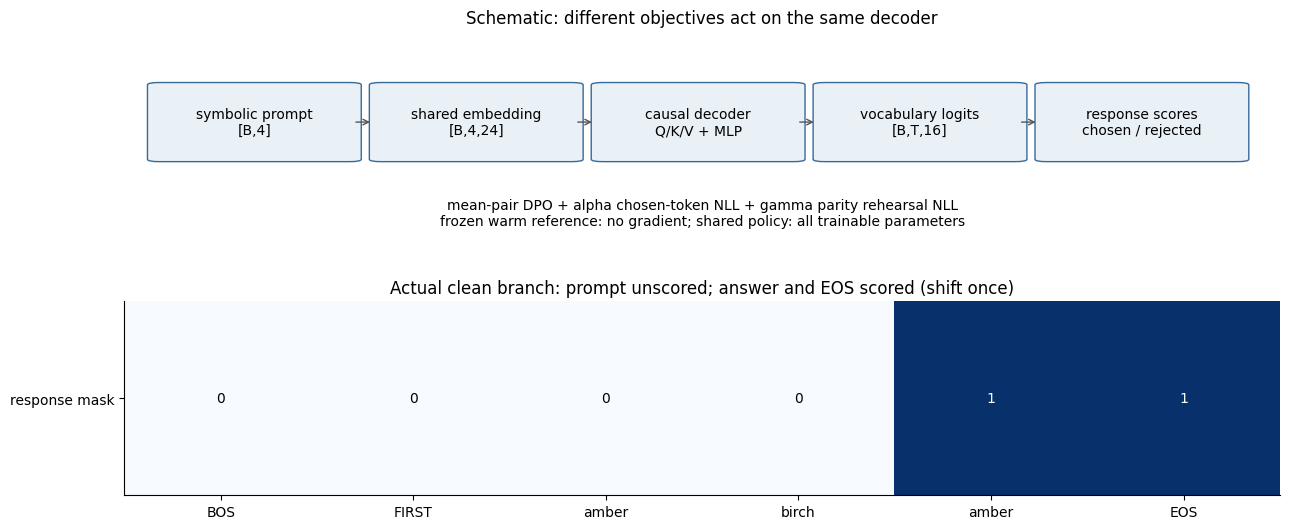

In [3]:
chosen,rejected,train_items = lab.pair_batches(contract,"clean")
fig,axes = plt.subplots(2,1,figsize=(13,5.4),gridspec_kw={"height_ratios":[1.2,1]})
ax = axes[0]; ax.set(xlim=(0,1),ylim=(0,1)); ax.axis("off")
texts = ["symbolic prompt\n[B,4]","shared embedding\n[B,4,24]",
         "causal decoder\nQ/K/V + MLP","vocabulary logits\n[B,T,16]","response scores\nchosen / rejected"]
for i,text in enumerate(texts):
    x = .03+i*.192
    ax.add_patch(FancyBboxPatch((x,.45),.165,.32,boxstyle="round,pad=0.01",facecolor="#eaf1f6",edgecolor=colors[0]))
    ax.text(x+.0825,.61,text,ha="center",va="center")
    if i < 4:
        ax.annotate("",xy=(x+.185,.61),xytext=(x+.168,.61),arrowprops={"arrowstyle":"->","color":"#555555"})
ax.text(.5,.22,"mean-pair DPO + alpha chosen-token NLL + gamma parity rehearsal NLL\n"
                 "frozen warm reference: no gradient; shared policy: all trainable parameters",ha="center",va="center")
ax.set_title("Schematic: different objectives act on the same decoder")
mask = chosen[2][0].numpy()[None,:].astype(int)
axes[1].imshow(mask,cmap="Blues",vmin=0,vmax=1,aspect="auto")
tokens = chosen[0][0].tolist()
axes[1].set_xticks(range(len(tokens)),[lab.render([x],contract) for x in tokens])
axes[1].set_yticks([0],["response mask"])
for j,value in enumerate(mask[0]):
    axes[1].text(j,0,str(value),ha="center",va="center",color="white" if value else "black")
axes[1].set_title("Actual clean branch: prompt unscored; answer and EOS scored (shift once)")
plt.tight_layout(); plt.show()


![Shared decoder objective schematic and actual prompt/answer/EOS loss-mask diagram](../figures/chapter-11/day-18-02_dpo_retention_and_preference_controls-01.png)

Saved reference output. Rerun the preceding plot cell to regenerate current results; editing a parameter does not refresh this fixed image.


Solution: the tasks share embeddings, attention, MLPs and output weights, so gradients from one task can change another task even without seeing its labels. Chosen NLL adds absolute pressure on recorded copying winners; rehearsal supplies explicit parity demonstrations. Common BOS/EOS tokens are shared; copying and parity operand/result symbols otherwise differ. Neither auxiliary guarantees every capability.

## 2. Prediction: what does alpha=0 recover?

For chosen sequence scores c, lengths T and hard DPO labels:
L = mean softplus(-m) + alpha*(-sum c / sum T) + gamma*N_rehearsal.

With nonzero gamma, does alpha=0 recover ordinary DPO? Why use a global token mean rather than a mean of per-response means?


In [4]:
pc = torch.tensor([-1.,-2.],dtype=torch.float64,requires_grad=True)
pr = torch.tensor([-2.,-3.],dtype=torch.float64,requires_grad=True)
rc = pc.detach().clone().requires_grad_(); rr = pr.detach().clone().requires_grad_()
lengths = torch.tensor([2,4])
rehearsal = torch.tensor(2.5,dtype=torch.float64,requires_grad=True)
plain,_ = dpo_loss(pc,pr,rc,rr,beta=.5)
zero,_ = lab.combined_loss(pc,pr,rc,rr,lengths,beta=.5,alpha=0,gamma=0)
assert torch.equal(plain,zero)
assert torch.equal(torch.autograd.grad(plain,pc,retain_graph=True)[0],
                   torch.autograd.grad(zero,pc,retain_graph=True)[0])
combined,parts = lab.combined_loss(pc,pr,rc,rr,lengths,beta=.5,alpha=.25,gamma=.25,rehearsal_nll=rehearsal)
grads = torch.autograd.grad(combined,(pc,pr,rc,rr,rehearsal),allow_unused=True)
expected_chosen = torch.full_like(pc,-.5/(2*2)-.25/6)
torch.testing.assert_close(grads[0],expected_chosen)
assert grads[2] is None and grads[3] is None
print("Chosen global token NLL:",float(parts["chosen_nll"].detach()),"not per-response mean:",
      float((-pc/lengths).mean().detach()))
print("Gradients chosen/rejected/reference/rehearsal:",grads)


Chosen global token NLL: 0.5 not per-response mean: 0.5
Gradients chosen/rejected/reference/rehearsal: (tensor([-0.1667, -0.1667], dtype=torch.float64), tensor([0.1250, 0.1250], dtype=torch.float64), None, None, tensor(0.2500, dtype=torch.float64))


Solution: alpha=gamma=0 recovers the original value and gradient exactly. With gamma>0, rehearsal is still an additional parameter-gradient term. The chosen coefficient contributes -alpha/sum(T) to every summed chosen score; global token weighting is different when lengths differ. Frozen reference tensors have no gradient. Independent tests also check the explicit combined expression against gradients of the actual decoder parameters.

## 3. Prediction: can a good margin coexist with forgetting?

Freeze your prediction before running this cell. The full reference executes all 48 small fits: 3 seeds × 4 conditions × 4 arms, plus a jointly supervised warm-up per seed. There is no early stopping or held-out checkpoint selection.


In [5]:
result = lab.run_retention(contract)
assert result["primary_recipe"] and result["all_predeclared_rows_retained"]
assert len(result["runs"]) == 48
assert all(x["reference_unchanged"] and x["cache_equal"] and not x["reference_has_gradients"] for x in result["runs"])
def selected(arm,condition="clean"):
    return [x for x in result["runs"] if x["arm"]["name"]==arm and x["condition"]==condition]
def metric(run,slice_name,key="canonical_complete_success"):
    return run["final"]["summaries"][slice_name][key]
print("Actual fits:",len(result["runs"]),"seconds:",round(result["seconds"],3))
for warm in result["warmups"]:
    print("Seed",warm["seed"],"random→warm canonical:",
          {k:(warm["initial"]["summaries"][k]["canonical_complete_success"],
              warm["warm"]["summaries"][k]["canonical_complete_success"]) for k in warm["warm"]["summaries"]})
print("All condition/arm endpoints, not a selected best arm:")
for condition in conditions:
    for arm in arms:
        rows = selected(arm,condition)
        print(condition,arm,"heldout copying:",[metric(x,"first/heldout") for x in rows],
              "trained parity retention:",[metric(x,"parity/train") for x in rows])


Actual fits: 48 seconds: 12.365
Seed 1811 random→warm canonical: {'first/train': (0.0, 1.0), 'first/heldout': (0.0, 0.0), 'parity/train': (0.0, 0.75), 'parity/heldout': (0.0, 0.5)}
Seed 1812 random→warm canonical: {'first/train': (0.0, 1.0), 'first/heldout': (0.0, 0.0), 'parity/train': (0.0, 0.5), 'parity/heldout': (0.0, 0.0)}
Seed 1813 random→warm canonical: {'first/train': (0.0, 1.0), 'first/heldout': (0.0, 0.0), 'parity/train': (0.0, 0.5), 'parity/heldout': (0.0, 0.5)}
All condition/arm endpoints, not a selected best arm:
clean dpo heldout copying: [0.0, 0.25, 0.0] trained parity retention: [0.5, 0.0, 0.5]
clean dpo+chosen heldout copying: [0.0, 0.25, 0.25] trained parity retention: [0.5, 0.0, 0.0]
clean dpo+rehearsal heldout copying: [0.25, 0.5, 0.0] trained parity retention: [1.0, 0.75, 1.0]
clean dpo+chosen+rehearsal heldout copying: [0.0, 0.25, 0.0] trained parity retention: [1.0, 0.75, 1.0]
noisy dpo heldout copying: [0.0, 0.0, 0.0] trained parity retention: [0.0, 0.25, 0.0]
no

Reference plot: each column uses the same clean pairs but a different fixed auxiliary objective. Top: absolute sequence log-likelihoods, including EOS. Bottom: reference-relative pair margin. Lines are three-seed means; bands are min/max across only those seeds, not confidence intervals.


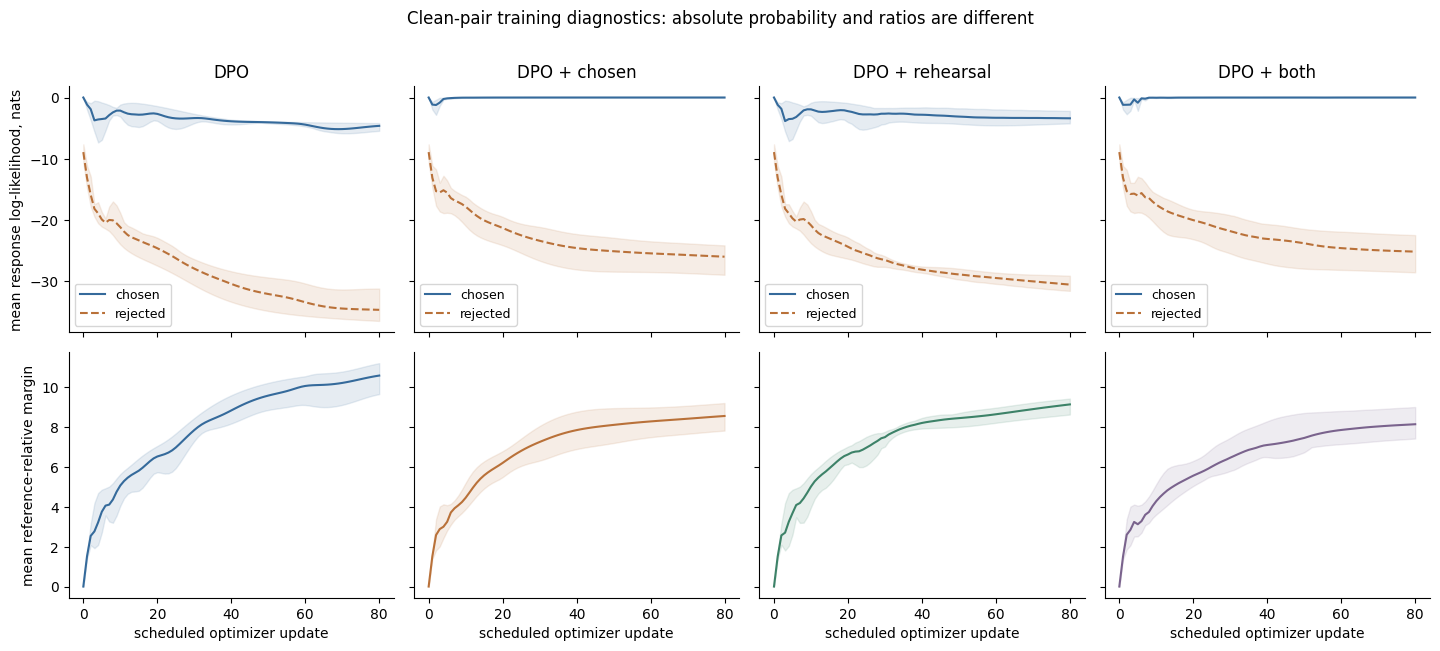

In [6]:
fig,axes = plt.subplots(2,4,figsize=(14.5,6.4),sharex=True,sharey="row")
for column,arm in enumerate(arms):
    rows = selected(arm)
    for key,label,style,color in [("chosen_log_likelihood","chosen","-",colors[0]),
                                 ("rejected_log_likelihood","rejected","--",colors[1])]:
        values = np.array([[r["initial_pair"][key]]+[h[key] for h in r["history"]] for r in rows])
        x = np.arange(values.shape[1])
        axes[0,column].plot(x,values.mean(0),style,color=color,label=label)
        axes[0,column].fill_between(x,values.min(0),values.max(0),color=color,alpha=.12)
    values = np.array([[0.]+[h["reference_relative_margin"] for h in r["history"]] for r in rows])
    axes[1,column].plot(x,values.mean(0),color=colors[column])
    axes[1,column].fill_between(x,values.min(0),values.max(0),color=colors[column],alpha=.12)
    axes[0,column].set_title(labels[column]); axes[0,column].legend(fontsize=9)
    axes[1,column].set_xlabel("scheduled optimizer update")
axes[0,0].set_ylabel("mean response log-likelihood, nats")
axes[1,0].set_ylabel("mean reference-relative margin")
fig.suptitle("Clean-pair training diagnostics: absolute probability and ratios are different",y=1.01)
plt.tight_layout(); plt.show()


![Actual chosen and rejected absolute log-likelihoods and DPO margins for all fixed clean arms](../figures/chapter-11/day-18-02_dpo_retention_and_preference_controls-02.png)

Saved reference output. Rerun the preceding plot cell to regenerate current results; editing a parameter does not refresh this fixed image.


Solution: a ratio can improve through a rejected-likelihood decline without a chosen-likelihood gain. Added NLL explicitly changes that pressure, but shared parameters still couple tasks. A low own loss or large margin is not free-generation accuracy. Do not compare differently augmented raw losses as a quality ranking.

## 4. Prediction: what is retained, and what actually generalizes?

Untouched warm checkpoints are the initial controls for each seed. Copying held-outs have unseen ordered pairs of already seen color tokens; parity training rows measure separate-task retention. Every score below comes from full-vocabulary greedy generation consuming its own outputs, cap4, and exact answer+EOS comparison.


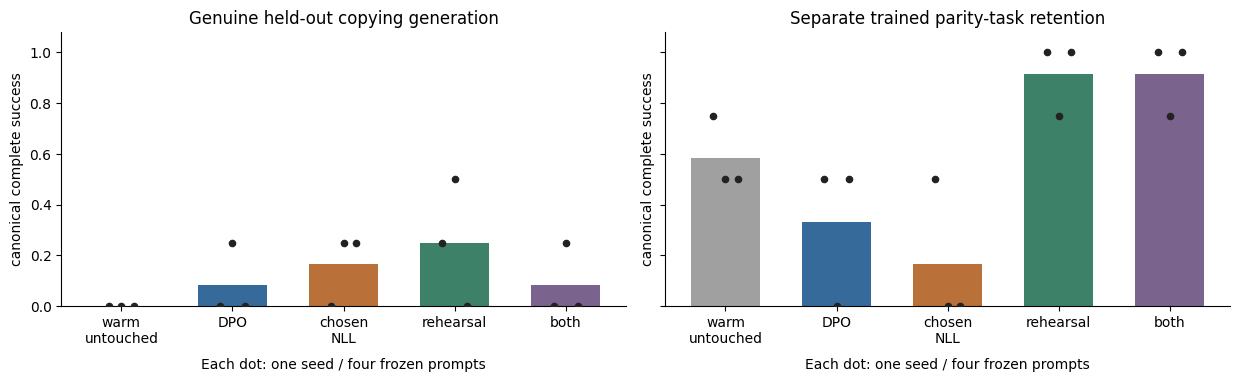

All clean-arm failures retained: 112
seed1811-clean-dpo-update80 copy-train-0 odd EOS expected [6, 2] eos
seed1811-clean-dpo-update80 copy-train-1 amber dune dune coral expected [7, 2] max_tokens
seed1811-clean-dpo-update80 copy-train-3 dune coral EOS expected [9, 2] eos
seed1811-clean-dpo-update80 parity-train-1 even EOS expected [15, 2] eos
seed1811-clean-dpo-update80 parity-train-2 even EOS expected [15, 2] eos
seed1811-clean-dpo-update80 copy-test-0 amber dune dune coral expected [6, 2] max_tokens
seed1811-clean-dpo-update80 copy-test-1 coral amber EOS expected [7, 2] eos
seed1811-clean-dpo-update80 copy-test-2 dune coral EOS expected [8, 2] eos
seed1811-clean-dpo-update80 copy-test-3 amber dune EOS expected [9, 2] eos
seed1811-clean-dpo-update80 parity-test-1 amber dune coral amber expected [15, 2] max_tokens
seed1811-clean-dpo-update80 parity-test-2 even EOS expected [15, 2] eos
seed1811-clean-dpo-update80 parity-test-3 amber dune coral amber expected [14, 2] max_tokens
seed1811-

In [7]:
fig,axes = plt.subplots(1,2,figsize=(12.5,4),sharey=True)
for ax,slice_name,title in zip(axes,["first/heldout","parity/train"],
                              ["Genuine held-out copying generation","Separate trained parity-task retention"]):
    before = [w["warm"]["summaries"][slice_name]["canonical_complete_success"] for w in result["warmups"]]
    groups = [before]+[[metric(x,slice_name) for x in selected(arm)] for arm in arms]
    ax.bar(range(5),[np.mean(g) for g in groups],color=["#a0a0a0"]+colors,width=.62)
    for i,g in enumerate(groups):
        ax.scatter([i-.11,i,i+.11],g,color="#222222",s=20,zorder=3)
    ax.set_xticks(range(5),["warm\nuntouched","DPO","chosen\nNLL","rehearsal","both"])
    ax.set(title=title,ylim=(0,1.08),ylabel="canonical complete success")
    ax.text(.5,-.23,"Each dot: one seed / four frozen prompts",transform=ax.transAxes,ha="center")
plt.tight_layout(); plt.show()
failures = [x for r in result["runs"] if r["condition"]=="clean" for x in r["final"]["rows"]
            if not x["canonical_complete_success"]]
print("All clean-arm failures retained:",len(failures))
for x in failures:
    print(x["checkpoint"],x["id"],x["raw_response"],"expected",x["expected"],x["stop_reason"])


![Paired warm-control and final full-generation scores for held-out copying and separate-task retention](../figures/chapter-11/day-18-02_dpo_retention_and_preference_controls-03.png)

Saved reference output. Rerun the preceding plot cell to regenerate current results; editing a parameter does not refresh this fixed image.


Solution: separate these observations. The warm control itself retains failures: parity succeeds on only 3/4, 2/4 and 2/4 trained rows, and held-out copying is 0/4 for all seeds. Rehearsal therefore also continues an imperfectly learned task; its gain is not an isolated anti-forgetting measurement. Preserving the four trained parity rows is retention, not proof of arithmetic transfer. Held-out parity has unseen numeral token embeddings and remains a separate severe-novelty result in the raw records. A higher held-out copying score establishes only this symbolic rule under this generation contract. Small fixed slices and three seeds do not support a universal method ranking.

## 5. Prediction: can extra chosen NLL repair wrong winners or unwanted verbosity?

Noisy pairs swap exactly two fixed winners. Longer-chosen pairs put STYLE STYLE before EOS only on the winner. Matched-long pairs do so on both branches. The evaluation target stays the short answer+EOS. Predict first-answer and complete-success behavior separately.


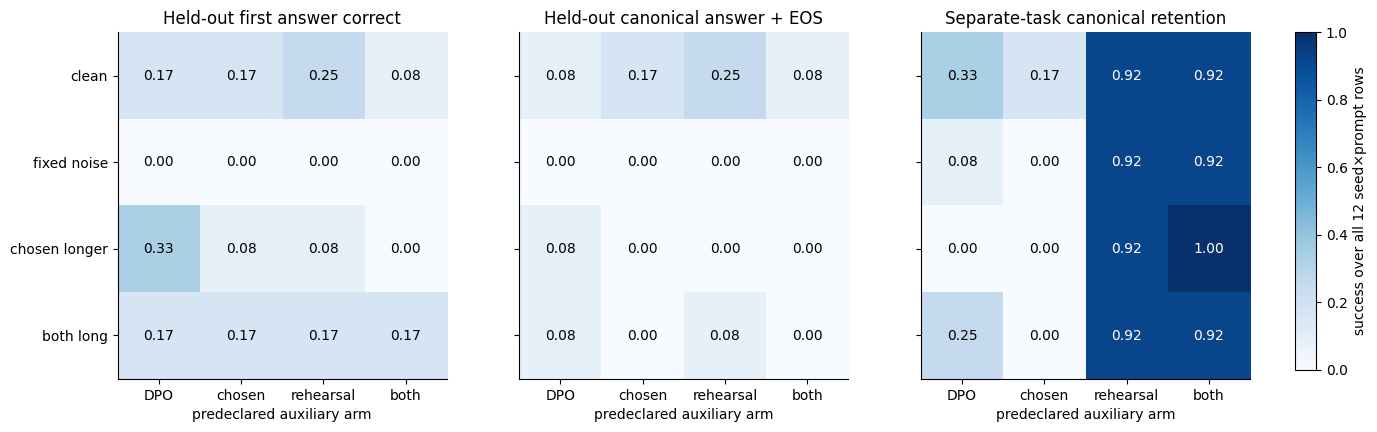

In [8]:
keys = [("first/heldout","first_answer_correct","Held-out first answer correct"),
        ("first/heldout","canonical_complete_success","Held-out canonical answer + EOS"),
        ("parity/train","canonical_complete_success","Separate-task canonical retention")]
fig,axes = plt.subplots(1,3,figsize=(15,4.5),sharey=True)
for ax,(slice_name,key,title) in zip(axes,keys):
    values = np.array([[np.mean([metric(r,slice_name,key) for r in selected(arm,condition)])
                       for arm in arms] for condition in conditions])
    im = ax.imshow(values,vmin=0,vmax=1,cmap="Blues",aspect="auto")
    for i in range(4):
        for j in range(4):
            ax.text(j,i,f"{values[i,j]:.2f}",ha="center",va="center",color="white" if values[i,j]>.55 else "black")
    ax.set_xticks(range(4),["DPO","chosen","rehearsal","both"])
    ax.set_yticks(range(4),["clean","fixed noise","chosen longer","both long"])
    ax.set_title(title); ax.set_xlabel("predeclared auxiliary arm")
fig.subplots_adjust(right=.88,wspace=.22)
color_axis = fig.add_axes([.91,.13,.014,.75])
fig.colorbar(im,cax=color_axis,label="success over all 12 seed×prompt rows")
plt.show()


![Fixed noisy-label and branch-length control grid with first-answer, complete-generation and retention metrics](../figures/chapter-11/day-18-02_dpo_retention_and_preference_controls-04.png)

Saved reference output. Rerun the preceding plot cell to regenerate current results; editing a parameter does not refresh this fixed image.


Solution: chosen NLL reinforces the recorded winner, even when it is wrong or carries an extra style. Matched-long removes the branch length asymmetry, not the style intervention. Treat first-answer accuracy and canonical stopping/format as distinct. All wrong, invalid and truncated paths remain in denominators; the repeated STYLE tokens are symbolic, not evidence about natural-language verbosity.

## 6. Prediction: are equal updates an equal-cost comparison?

Chosen NLL reuses the chosen pair score, so it adds objective supervision but no extra chosen forward. Rehearsal adds separate parity targets and one extra training forward per update. Diagnostics also consume forwards in every arm.


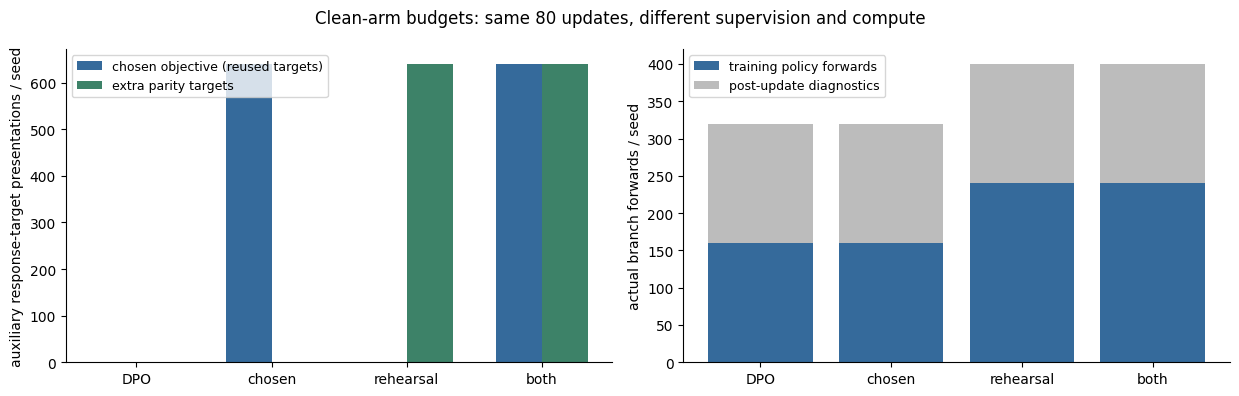

Warm-up targets per seed: [1920, 1920, 1920]
Pair-score targets / update across conditions: {'clean': 16, 'noisy': 16, 'chosen-longer': 24, 'matched-long': 32}
Each fit additionally makes 2 frozen-reference cache + 2 verification forwards.
Generation and expected-answer scoring costs remain in every saved output row.


In [9]:
clean_rows = [selected(arm)[0] for arm in arms]  # identical declared budgets for each seed
fig,axes = plt.subplots(1,2,figsize=(12.5,4))
x = np.arange(4)
axes[0].bar(x-.17,[r["costs"]["chosen_aux_supervised_tokens"] for r in clean_rows],width=.34,color=colors[0],label="chosen objective (reused targets)")
axes[0].bar(x+.17,[r["costs"]["rehearsal_supervised_tokens"] for r in clean_rows],width=.34,color=colors[2],label="extra parity targets")
axes[0].set_ylabel("auxiliary response-target presentations / seed")
axes[0].legend(fontsize=9)
training = np.array([r["costs"]["training_policy_forwards"] for r in clean_rows])
diagnostic = np.array([r["costs"]["diagnostic_policy_forwards"] for r in clean_rows])
axes[1].bar(x,training,color=colors[0],label="training policy forwards")
axes[1].bar(x,diagnostic,bottom=training,color="#bcbcbc",label="post-update diagnostics")
axes[1].set_ylabel("actual branch forwards / seed"); axes[1].legend(fontsize=9)
for ax in axes: ax.set_xticks(x,["DPO","chosen","rehearsal","both"])
fig.suptitle("Clean-arm budgets: same 80 updates, different supervision and compute")
plt.tight_layout(); plt.show()
print("Warm-up targets per seed:",[w["supervised_response_tokens"] for w in result["warmups"]])
print("Pair-score targets / update across conditions:",
      {c:next(r["costs"]["pair_score_response_tokens"]//r["updates"] for r in result["runs"] if r["condition"]==c) for c in conditions})
print("Each fit additionally makes 2 frozen-reference cache + 2 verification forwards.")
print("Generation and expected-answer scoring costs remain in every saved output row.")


![Added chosen/rehearsal supervision and actual training/diagnostic forward budgets](../figures/chapter-11/day-18-02_dpo_retention_and_preference_controls-05.png)

Saved reference output. Rerun the preceding plot cell to regenerate current results; editing a parameter does not refresh this fixed image.


Solution: do not add the reused chosen auxiliary targets to the pair processing count as if they were new data or forwards. Rehearsal targets and forwards are additional. Long-pair conditions process more response tokens even with the same pair/update count. No wall-time efficiency ranking follows from this figure; runtime, padded work and generation costs need their own accounting.

## Evidence boundary and next intervention

Explain one retained regression from its generated tokens, not only the scalar score. If you change alpha, gamma, labels, template or cap, record a new experiment; do not select the apparent best coefficient from these final-test rows. The fixed recipe is a controlled comparison, not a universal retention repair.

The historical negative DPO experiment remains unchanged. This notebook verifies mechanisms and the symbolic scope only. Pretrained SFT→DPO retention, human-preference validity, broader language quality and Spark-scale safety require separately approved evidence. No animations are rendered here.
